# Terminal loading report (Yanbu zone + Crude + Muajjiz + CPC)

Desk pack per terminal:
1. Soft-language cover blurb (today / tomorrow slate)
2. Ras Laffan–style chart (breaks + occupancy + exports + events)
3. Loading slate (last 2 realized + next 2–3 forecast)
4. Latest clear Copernicus **raw** scene on Crude / Muajjiz / CPC (not zone)
5. CPC only: NDWI analyst debug panel (slots)

Writes a self-contained HTML file under `reports/`.

**Kernel:** repo `.venv`. Credentials from `vessel_crossing/.env` (`KPLER_EMAIL` / `KPLER_PASSWORD`, plus `SH_CLIENT_ID` / `SH_CLIENT_SECRET` for imagery).

## How to add another AOI / terminal

1. **Imagery AOI** (if you want a satellite panel): add polygon + slots in `copernicus_vessel_detection.ipynb` `AOI_CONFIG` (use a template from `aoi_config.py`).
2. **Report registry**: add a block under `terminals:` in `terminals.yaml`:
   - `kpler.name` / `kpler.kind` — same as Kpler UI filter
   - `imagery.aoi_key` + `imagery.geojson` — same polygon as the detection notebook
   - optional terminal-specific `events`
   - for zone “installation TBD” queues: `slate.require_blank_installation: true` and `report.include_gap_chart/flows/satellite: false` (see `yanbu_unallocated`)
3. Add the new id to `TERMINALS` below and re-run.

Ships with `yanbu` (zone consolidated), `yanbu_crude`, `muajjiz`, `yanbu_unallocated`, and `cpc`. Satellite only on Crude/Muajjiz/CPC. Detection counts stay out of the cover blurb on purpose.

In [5]:
from __future__ import annotations

import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, display

NOTEBOOK_DIR = Path.cwd()
for candidate in [
    NOTEBOOK_DIR,
    NOTEBOOK_DIR / "vessel_crossing" / "port_loading_gaps",
    NOTEBOOK_DIR / "port_loading_gaps",
]:
    if (candidate / "terminal_report.py").exists():
        NOTEBOOK_DIR = candidate
        break
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from loading_gaps import parse_env
from terminal_report import build_report, write_html

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "font.size": 10,
    }
)

BASE = NOTEBOOK_DIR.parent
ENV_PATH = BASE / ".env"
REPORTS_DIR = NOTEBOOK_DIR / "reports"

# --- controls ---
TERMINALS = ["yanbu", "yanbu_crude", "muajjiz", "yanbu_unallocated", "cpc"]
ASOF = date.today()  # or date(2026, 8, 6)
FETCH_SATELLITE = True  # set False for a fast Kpler-only draft
# Satellite panels: Crude / Muajjiz / CPC only (zone yanbu has include_satellite: false)

env = parse_env(ENV_PATH)
email = env.get("KPLER_EMAIL") or env.get("EMAIL")
password = env.get("KPLER_PASSWORD") or env.get("PASSWORD")
if not email or not password:
    raise RuntimeError(f"Missing KPLER_EMAIL/KPLER_PASSWORD in {ENV_PATH}")

print(f"as-of {ASOF}  terminals={TERMINALS}  sat={FETCH_SATELLITE}")


as-of 2026-08-11  terminals=['yanbu', 'yanbu_crude', 'muajjiz', 'yanbu_unallocated', 'cpc']  sat=True


Built 5 terminal section(s)


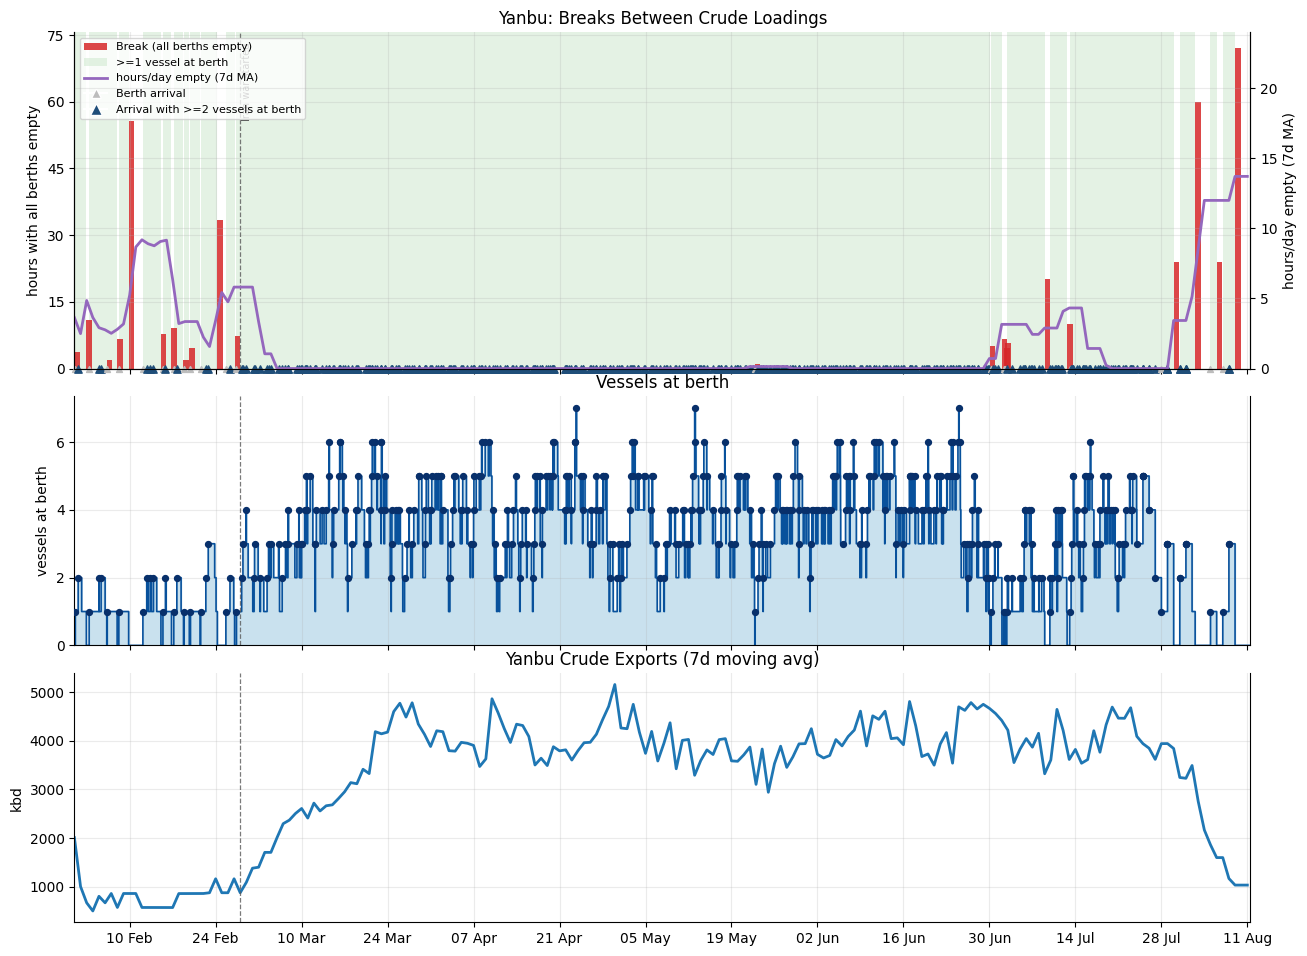

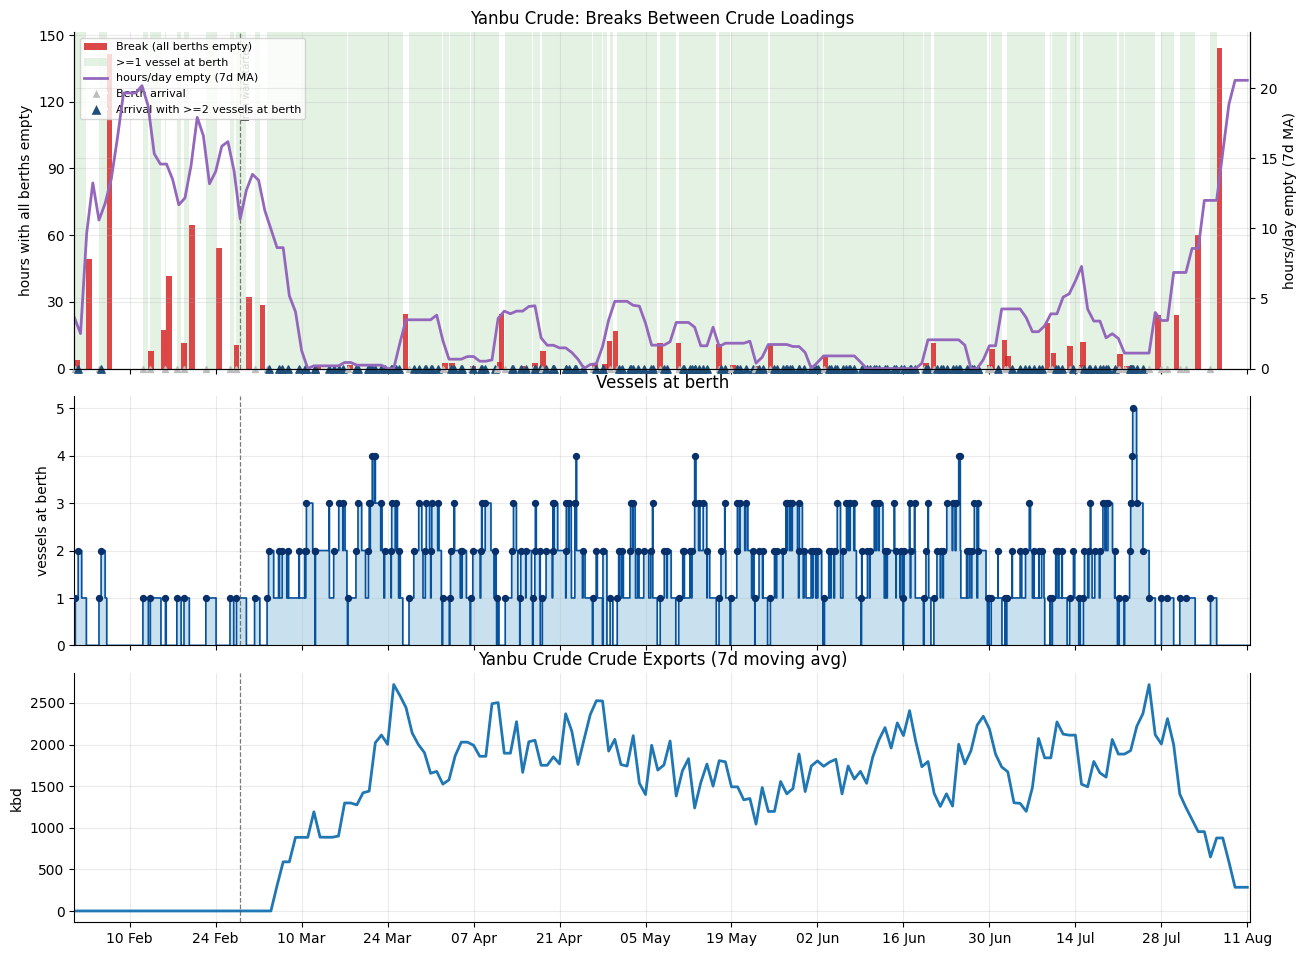

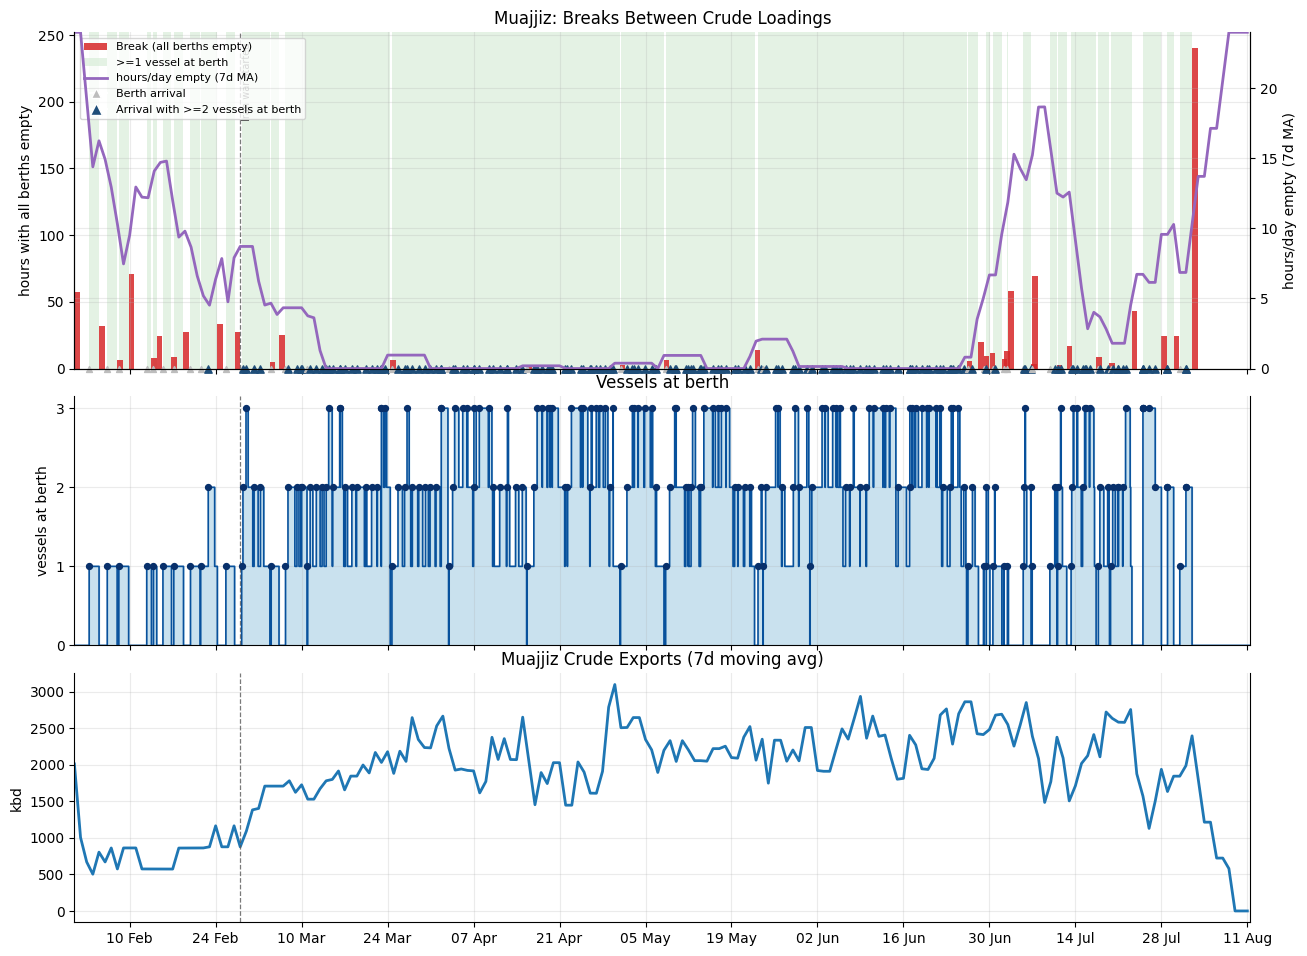

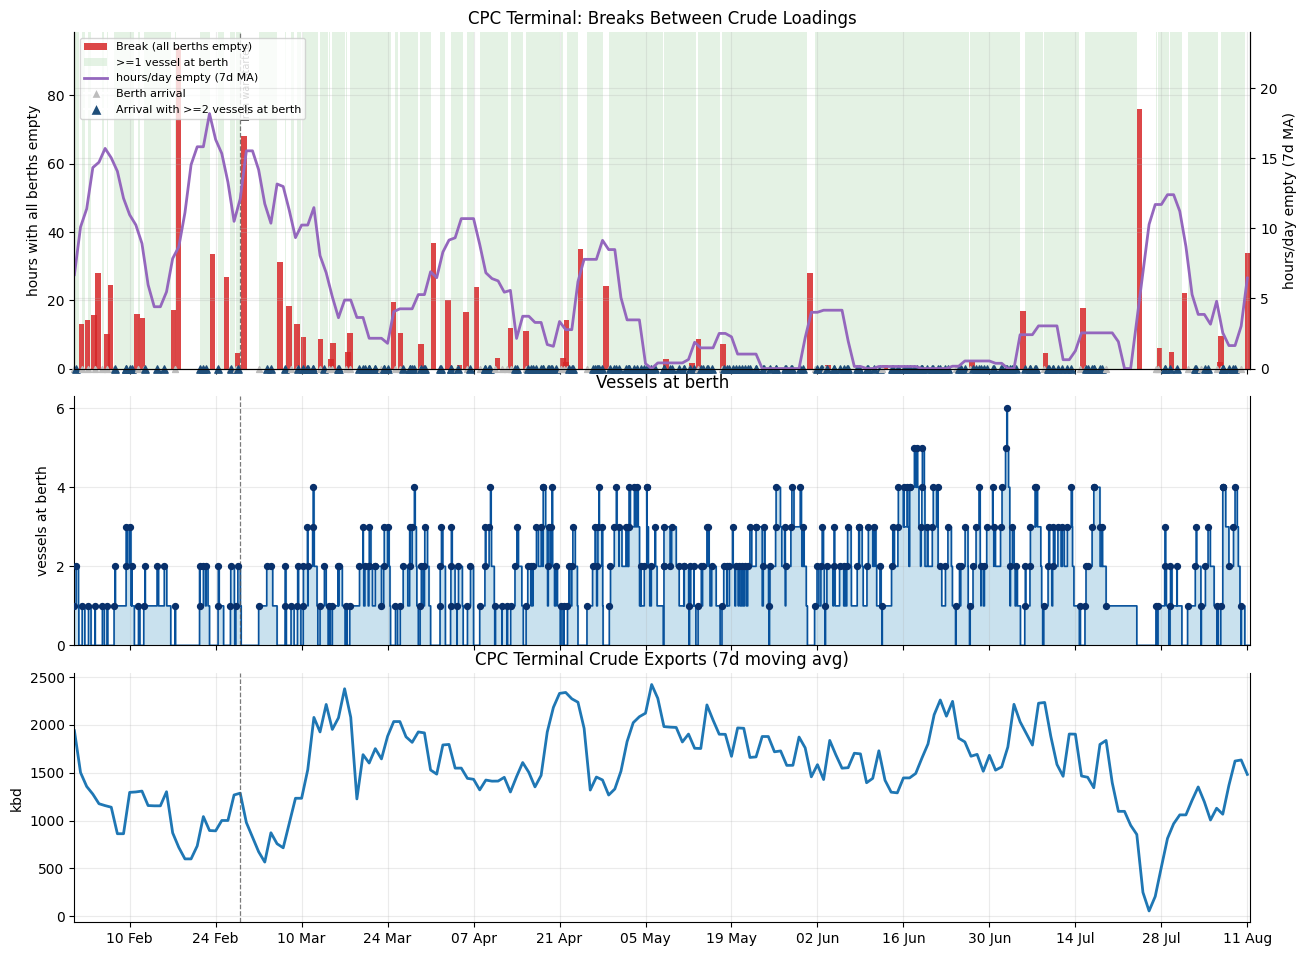

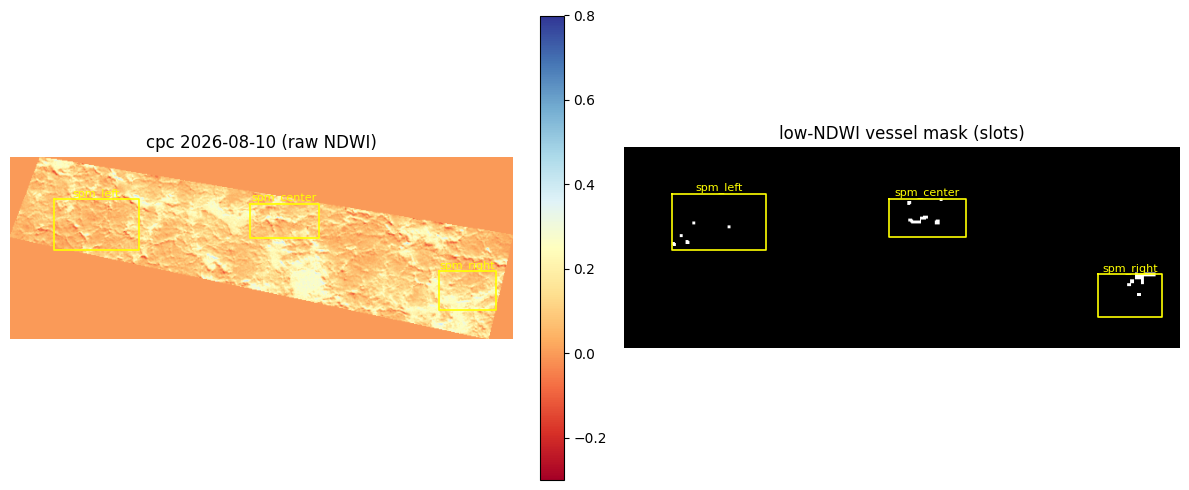

In [6]:
sections = build_report(
    TERMINALS,
    asof=ASOF,
    email=email,
    password=password,
    env=env,
    fetch_satellite=FETCH_SATELLITE,
)
print(f"Built {len(sections)} terminal section(s)")


Yanbu (zone)

No loadings dated today in the Kpler slate.
2 scheduled tomorrow: Roberta B (VLCC), Sahba (VLCC) [fixture].
Further forward: Ghazal, Minerva Zenobia, New Vanguard, Plata Glory, Andromeda, Lila Marseille.



,load_date,vessel,vessel_class,installation,grade,destination,kbbl,status,vs_asof
0,2026-08-08,Gabon Prosperity,VLCC,Yanbu (TBD),Arab,Ain Sukhna,2078.0,realized,-3d
1,2026-08-08,Seavoice,VLCC,Yanbu (TBD),Arab,Eastern Asia,1033.0,realized,-3d
2,2026-08-12,Roberta B,VLCC,Yanbu (TBD),Arab,,1989.0,fixture,+1d
3,2026-08-12,Sahba,VLCC,Yanbu (TBD),Arab,,2119.0,fixture,+1d
4,2026-08-13,Ghazal,VLCC,Yanbu (TBD),Arab,,2120.0,fixture,+2d
5,2026-08-13,Minerva Zenobia,LR2,Yanbu (TBD),Arab,Mangalore,775.0,fixture,+2d
6,2026-08-13,New Vanguard,VLCC,Yanbu (TBD),Arab,China,2058.0,fixture,+2d
7,2026-08-13,Plata Glory,VLCC,Yanbu (TBD),Arab,,2012.0,fixture,+2d
8,2026-08-14,Andromeda,VLCC,Yanbu (TBD),Arab,Ulsan,2165.0,fixture,+3d
9,2026-08-14,Lila Marseille,LR3,Yanbu (TBD),Arab,,1059.0,fixture,+3d


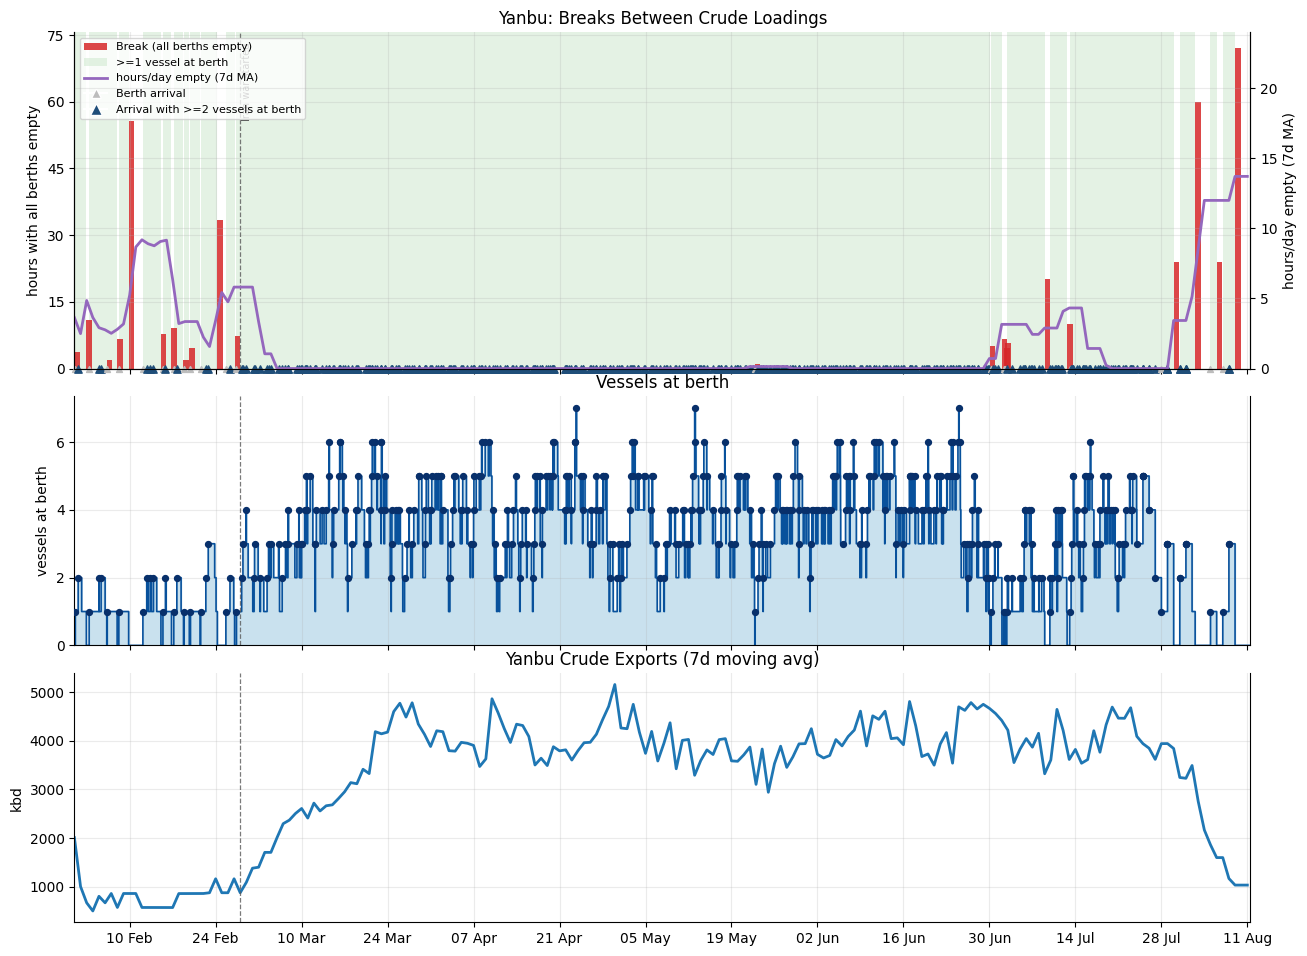

Yanbu Crude

No loadings dated today in the Kpler slate.

Latest clear Copernicus scene: 06-08-2026 (5d stale, cloud≈7%). Auto vessel count not used — human read: [add loadings / approach note].



,load_date,vessel,vessel_class,installation,grade,destination,kbbl,status,vs_asof
0,2026-08-05,V.Glory,VLCC,Yanbu Crude,Arab,Ain Sukhna,996.0,realized,-6d


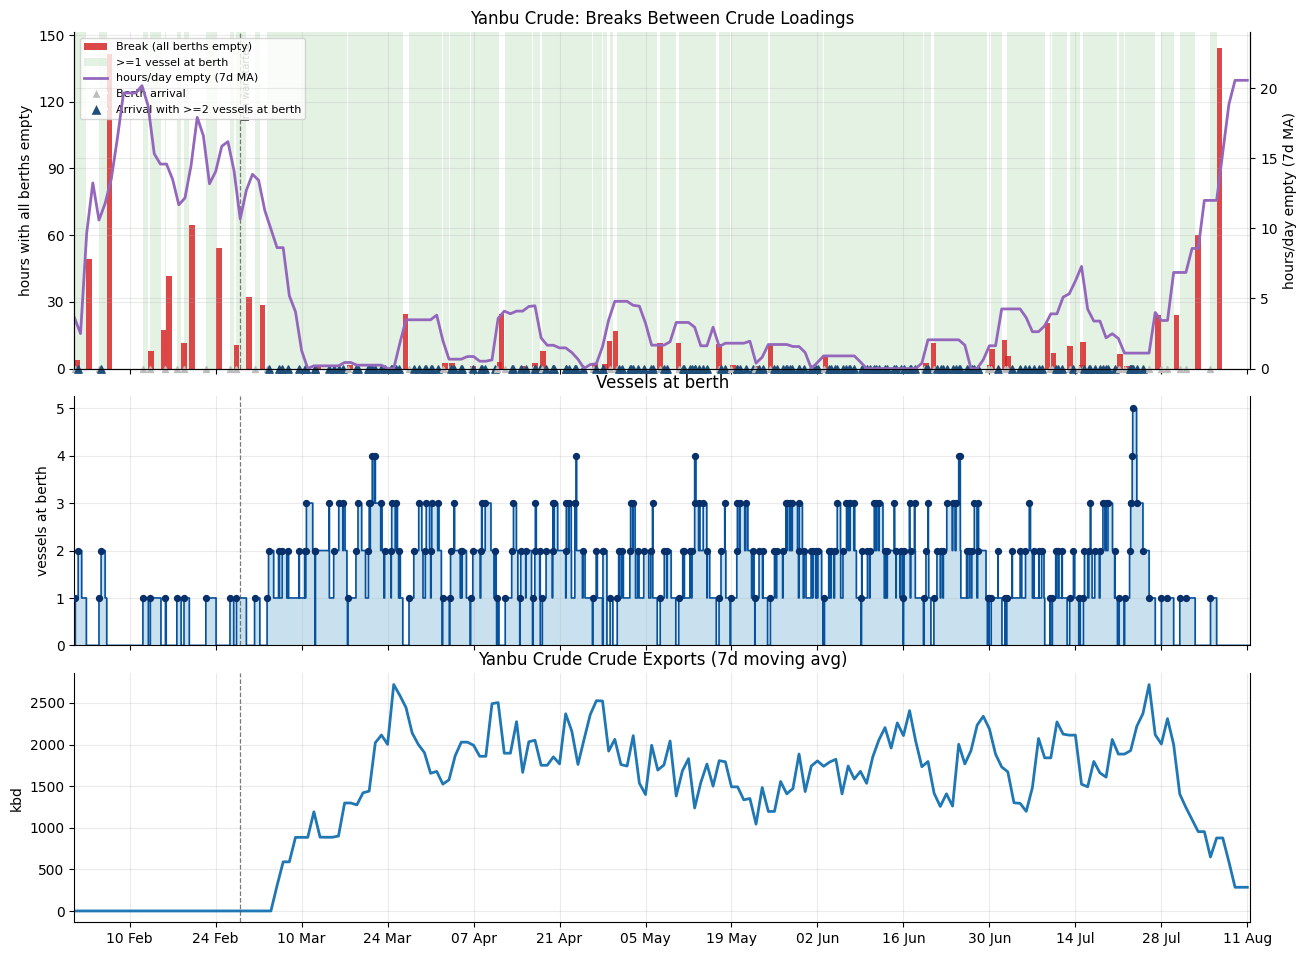

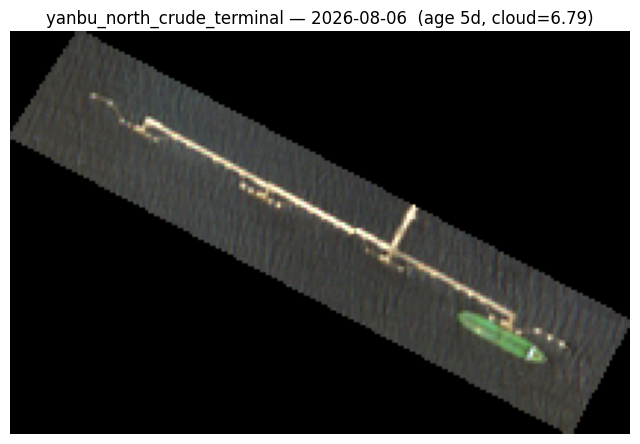

Muajjiz

No loadings dated today in the Kpler slate.

Latest clear Copernicus scene: 06-08-2026 (5d stale, cloud≈7%). Auto vessel count not used — human read: [add loadings / approach note].



,load_date,vessel,vessel_class,installation,grade,destination,kbbl,status,vs_asof
0,2026-08-01,Dht Puma,VLCC,Muajjiz,Arab,Ain Sukhna,2065.0,realized,-10d
1,2026-08-01,Roberta B,VLCC,Muajjiz,Arab,Ain Sukhna,1989.0,realized,-10d


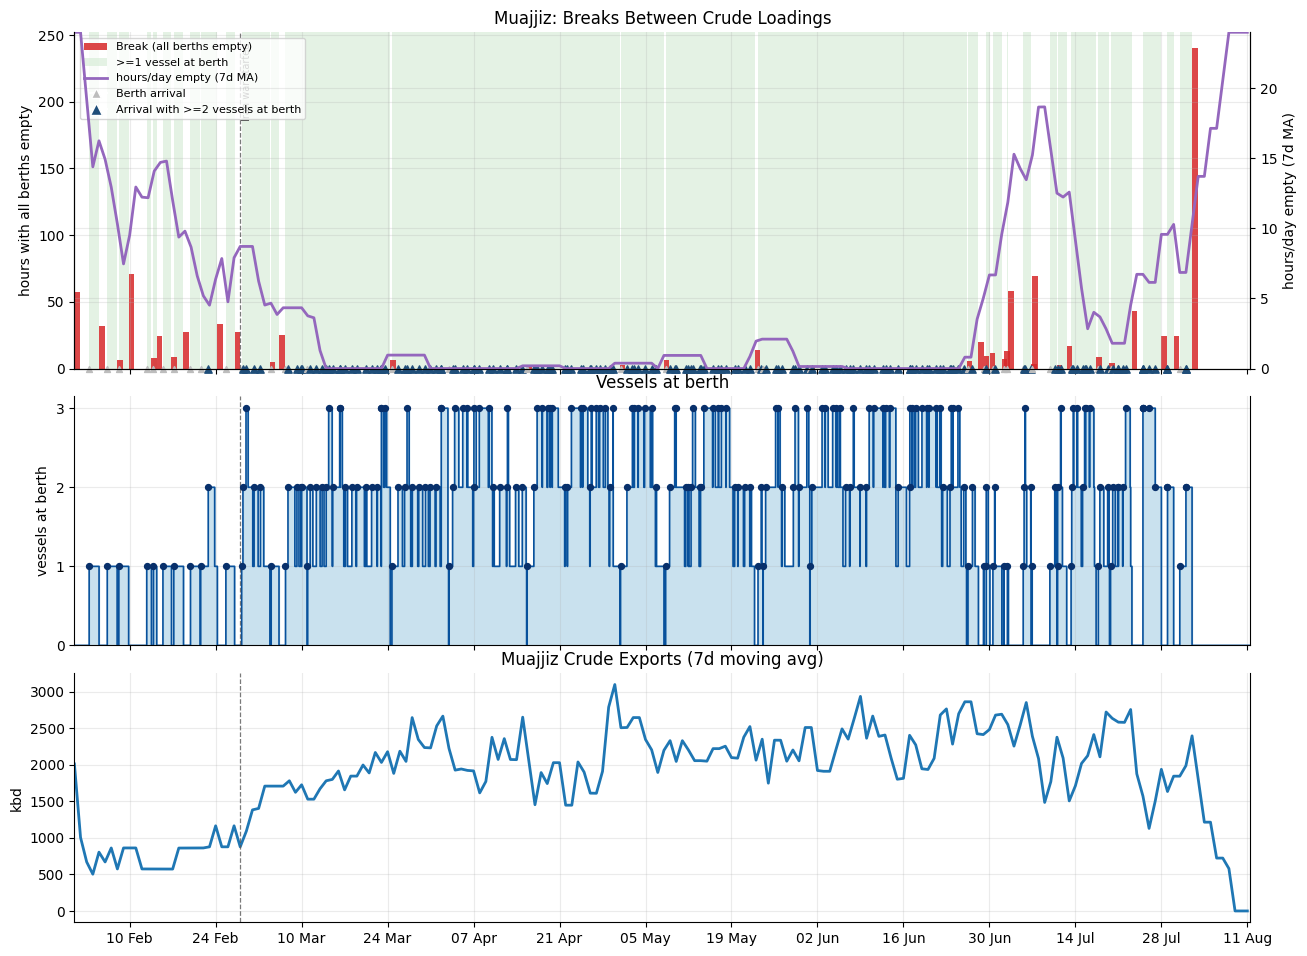

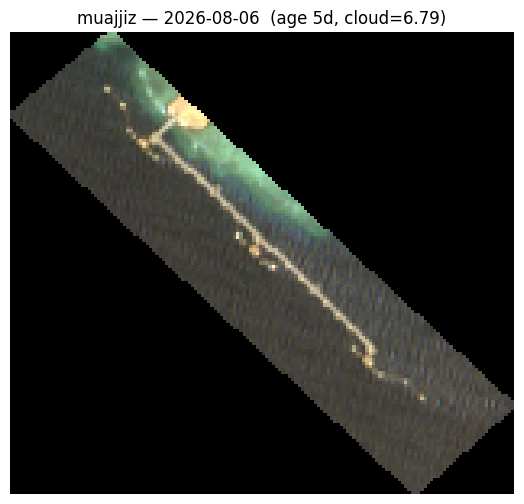

Yanbu — installation TBD

Kpler zone cargos with installation not yet assigned (may later resolve to a child installation).

No loadings dated today in the Kpler slate.
2 scheduled tomorrow: Roberta B (VLCC), Sahba (VLCC) [fixture].
Further forward: Ghazal, Minerva Zenobia, New Vanguard, Plata Glory, Andromeda, Lila Marseille, Mount Vision, Shalamar, Maran Aphrodite, Maran Leo.



,load_date,vessel,vessel_class,installation,grade,destination,kbbl,status,vs_asof
0,2026-08-08,Gabon Prosperity,VLCC,Yanbu (TBD),Arab,Ain Sukhna,2078.0,realized,-3d
1,2026-08-08,Seavoice,VLCC,Yanbu (TBD),Arab,Eastern Asia,1033.0,realized,-3d
2,2026-08-12,Roberta B,VLCC,Yanbu (TBD),Arab,,1989.0,fixture,+1d
3,2026-08-12,Sahba,VLCC,Yanbu (TBD),Arab,,2119.0,fixture,+1d
4,2026-08-13,Ghazal,VLCC,Yanbu (TBD),Arab,,2120.0,fixture,+2d
5,2026-08-13,Minerva Zenobia,LR2,Yanbu (TBD),Arab,Mangalore,775.0,fixture,+2d
6,2026-08-13,New Vanguard,VLCC,Yanbu (TBD),Arab,China,2058.0,fixture,+2d
7,2026-08-13,Plata Glory,VLCC,Yanbu (TBD),Arab,,2012.0,fixture,+2d
8,2026-08-14,Andromeda,VLCC,Yanbu (TBD),Arab,Ulsan,2165.0,fixture,+3d
9,2026-08-14,Lila Marseille,LR3,Yanbu (TBD),Arab,,1059.0,fixture,+3d


CPC

No loadings dated today in the Kpler slate.

Latest clear Copernicus scene: 10-08-2026 (1d stale, cloud≈29%). Auto vessel count not used — human read: [add loadings / approach note].



,load_date,vessel,vessel_class,installation,grade,destination,kbbl,status,vs_asof
0,2026-08-09,Seavision,LR3,CPC Terminal,CPC Kazakhstan,Italy,1062.0,realized,-2d
1,2026-08-10,Delta Kanaris,LR3,CPC Terminal,CPC Kazakhstan,Europe,1056.0,realized,-1d


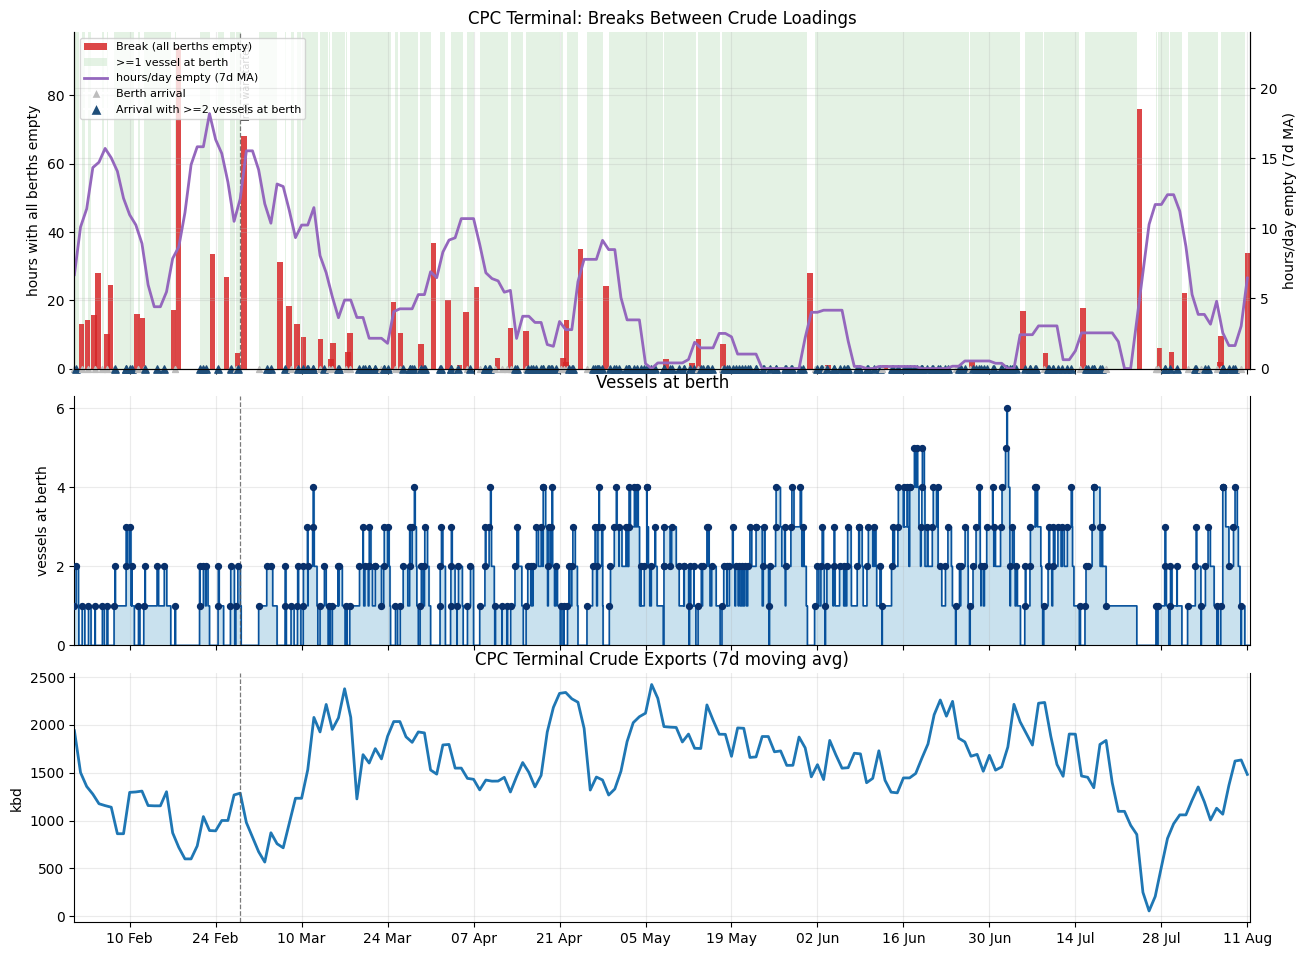

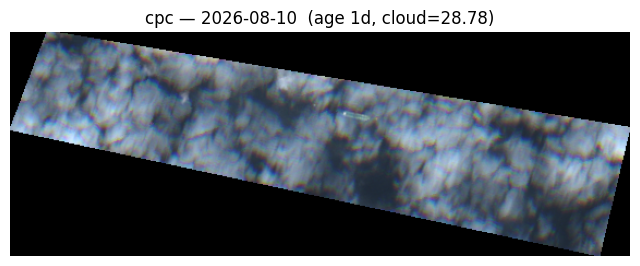

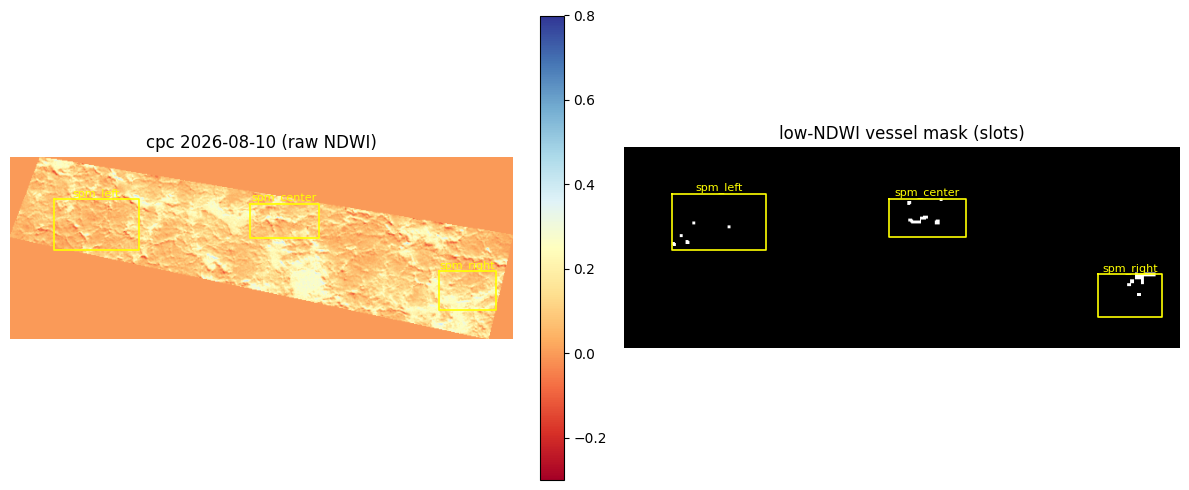

In [7]:
for sec in sections:
    print("=" * 60)
    print(sec.blurb)
    print()
    display(sec.slate)
    if sec.chart_fig is not None:
        display(sec.chart_fig)
    sat = sec.satellite
    if sat.rgb is not None and sat.scene_date is not None:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(sat.rgb)
        ax.set_title(
            f"{sat.aoi_key} — {sat.scene_date}  (age {sat.age_days}d, "
            f"cloud={sat.cloud_cover})"
        )
        ax.axis("off")
        plt.show()
        if sat.debug_fig is not None:
            display(sat.debug_fig)
            plt.close(sat.debug_fig)
    elif sat.note and sat.note != "Satellite fetch skipped.":
        print(sat.note)
    if sec.chart_fig is not None:
        plt.close(sec.chart_fig)


In [8]:
out_path = REPORTS_DIR / f"terminal_report_{ASOF:%Y-%m-%d}.html"
write_html(sections, out_path)
print(f"Wrote {out_path}")
# Uncomment to preview HTML inline:
#display(HTML(out_path.read_text(encoding="utf-8")))


Wrote c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\port_loading_gaps\reports\terminal_report_2026-08-11.html
